# Decision Trees from First Principles with pandas and scikit-learn

## A 3-hour hands-on classification lab

**Scope:** train and study *single decision-tree classifiers only*.

### Learning objectives

By the end of the lab, you will be able to:

1. Train a `DecisionTreeClassifier` with a reproducible train/test workflow.
2. Explain what a tree level (depth) represents.
3. Visualize how increasing `max_depth` changes:
   - the learned rules,
   - train/test performance,
   - tree size,
   - leaf purity,
   - feature importance.
4. Explain and manually verify impurity-based feature importance.
5. Compare the split criteria `"gini"`, `"entropy"`, and `"log_loss"`.
6. Recognize overfitting and limitations of impurity-based importance.

---

## Suggested timing

| Segment | Topic | Time |
|---|---|---:|
| 1 | Setup and Iris visual warm-up | 35 min |
| 2 | Breast-cancer data and first tree | 25 min |
| 3 | Purity and feature importance | 35 min |
| 4 | Depth sweep: levels 1 to X | 35 min |
| Break | Short break | 10 min |
| 5 | Criteria and final diagnosis | 25 min |
| 6 | Exercises and synthesis | 15 min |
| **Total** |  | **180 min** |

> This notebook uses a medical dataset for teaching only. It is not a diagnostic tool.

<a href="https://colab.research.google.com/github/w4bo/AA2627-unibo-mldm/blob/master/slides/lab-01-dt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

The notebook needs:

- Python 3.10+
- pandas
- NumPy
- matplotlib
- scikit-learn

Install missing packages with:

```bash
pip install pandas numpy matplotlib scikit-learn
```

In [85]:
#| echo: false
#| output: false
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
)

RANDOM_STATE = 42

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.14.3
pandas: 3.0.1
scikit-learn: 1.8.0


## 1. Iris warm-up: levels and features - 35 minutes

Before moving to the larger breast-cancer dataset, use the Iris dataset to build geometric intuition.

We keep only two features so each trained tree can be drawn as a decision boundary:

- `petal length (cm)`
- `petal width (cm)`

This small example makes two ideas visible:

1. A tree level adds another round of yes/no splits.
2. Each split is a threshold on one feature, so the boundary is made of horizontal and vertical steps.

In [86]:
#| echo: false
#| output: false
iris = load_iris(as_frame=True)

iris_features = ["petal length (cm)", "petal width (cm)"]
iris_X = iris.data[iris_features].copy()
iris_y = iris.target.copy()

iris_df = iris_X.copy()
iris_df["target"] = iris_y
iris_df["target_name"] = iris_y.map(dict(enumerate(iris.target_names)))


## Iris: dataset dimensions


In [87]:
#| echo: false
print("Feature matrix shape:", iris_X.shape)
print("Target shape:", iris_y.shape)


Feature matrix shape: (150, 2)
Target shape: (150,)


## Iris: data preview


In [88]:
#| echo: false
display(iris_df.head())


,petal length (cm),petal width (cm),target,target_name
0,1.4,0.2,0,setosa
1,1.4,0.2,0,setosa
2,1.3,0.2,0,setosa
3,1.5,0.2,0,setosa
4,1.4,0.2,0,setosa


### Plot the two-feature space

Each point is one flower. A decision tree trained on these two columns can only split the plane using feature thresholds.

In [89]:
#| echo: false
#| output: false
iris_colors = ["#4C78A8", "#F58518", "#54A24B"]
iris_class_colors = dict(enumerate(iris_colors))

def add_iris_points(ax, point_size=40):
    for class_id, class_name in enumerate(iris.target_names):
        mask = iris_y == class_id
        ax.scatter(
            iris_X.loc[mask, iris_features[0]],
            iris_X.loc[mask, iris_features[1]],
            color=iris_class_colors[class_id],
            edgecolor="black",
            linewidth=0.4,
            label=class_name,
            alpha=0.85,
            s=point_size,
        )

def plot_iris_feature_space():
    fig, ax = plt.subplots(figsize=(8, 6))
    add_iris_points(ax)
    ax.set_xlabel(iris_features[0])
    ax.set_ylabel(iris_features[1])
    ax.set_title("Iris classes using two petal features")
    ax.grid(alpha=0.25)
    ax.legend(title="Class")
    plt.show()


## Iris: feature-space plot


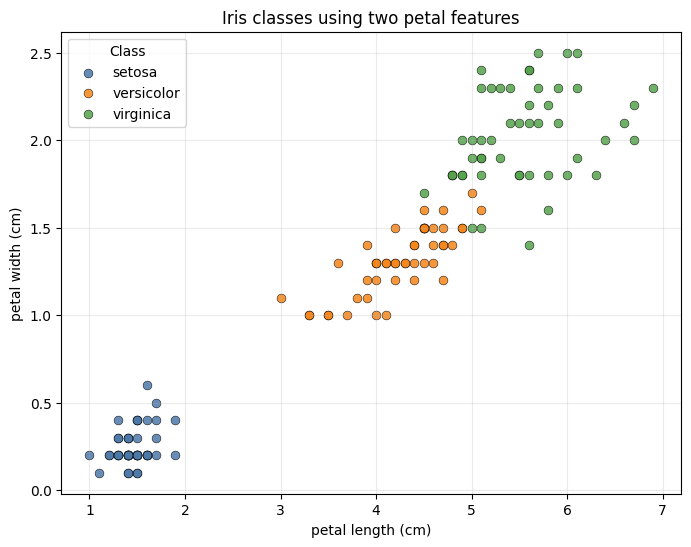

In [90]:
#| echo: false
plot_iris_feature_space()


### Train trees from depth 1 to X

The next chart trains one decision tree per depth. The colored background shows the class predicted for every point in the two-feature plane; the scatter points use the same colors for the observed classes.

In [91]:
#| echo: false
#| output: false
from matplotlib.colors import ListedColormap

IRIS_MAX_DEPTH = 5
iris_depths = list(range(1, IRIS_MAX_DEPTH + 1))
iris_cmap = ListedColormap(iris_colors)

x_min = iris_X[iris_features[0]].min() - 0.5
x_max = iris_X[iris_features[0]].max() + 0.5
y_min = iris_X[iris_features[1]].min() - 0.3
y_max = iris_X[iris_features[1]].max() + 0.3
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 350),
    np.linspace(y_min, y_max, 350),
)
iris_boundary_grid = pd.DataFrame({
    iris_features[0]: xx.ravel(),
    iris_features[1]: yy.ravel(),
})

iris_models_by_depth = {}
for depth in iris_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(iris_X, iris_y)
    iris_models_by_depth[depth] = model

def plot_iris_decision_boundary(depth):
    model = iris_models_by_depth[depth]
    grid_predictions = model.predict(iris_boundary_grid).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contourf(
        xx,
        yy,
        grid_predictions,
        levels=np.arange(len(iris.target_names) + 1) - 0.5,
        cmap=iris_cmap,
        alpha=0.25,
    )
    add_iris_points(ax, point_size=32)
    ax.set_xlabel(iris_features[0])
    ax.set_ylabel(iris_features[1])
    ax.set_title(
        f"max_depth={depth} | leaves={model.get_n_leaves()} | "
        f"train acc={model.score(iris_X, iris_y):.3f}"
    )
    ax.grid(alpha=0.18)
    ax.legend(title="Observed class")
    plt.show()


## Iris boundary: max depth 1


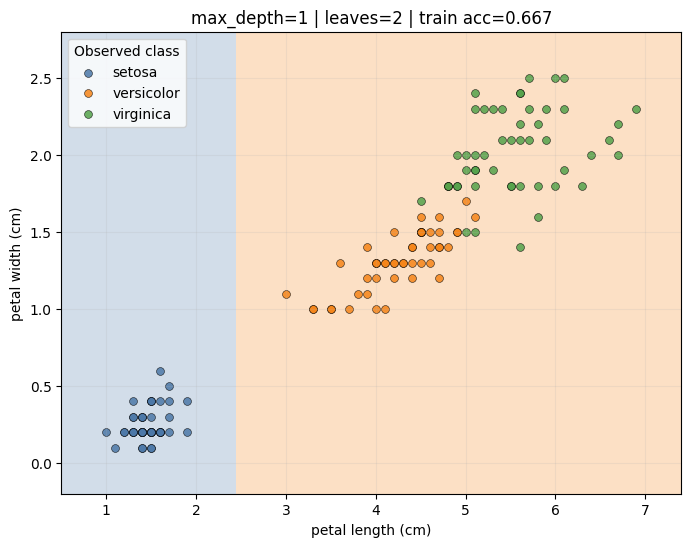

In [92]:
#| echo: false
plot_iris_decision_boundary(1)


## Iris boundary: max depth 2


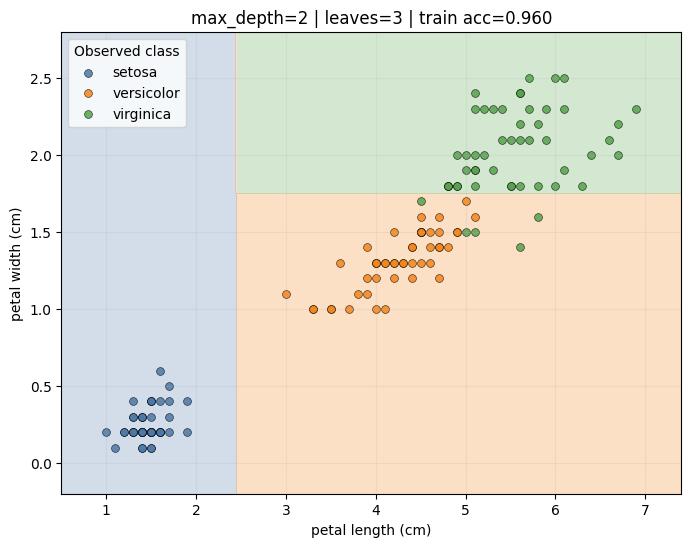

In [93]:
#| echo: false
plot_iris_decision_boundary(2)


## Iris boundary: max depth 3


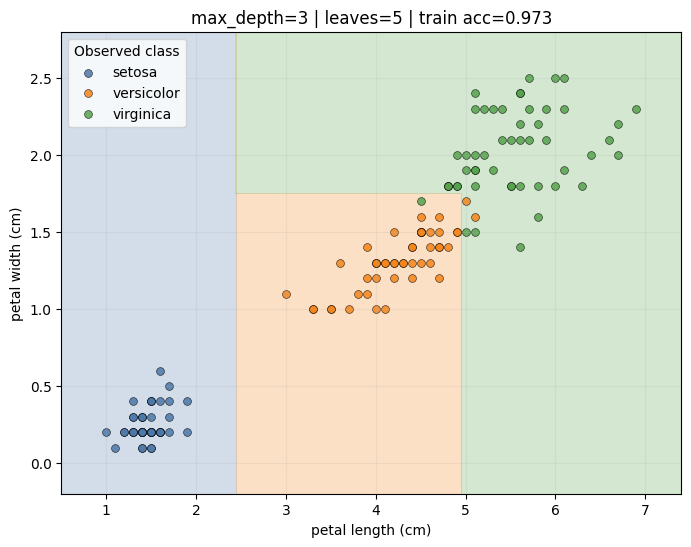

In [94]:
#| echo: false
plot_iris_decision_boundary(3)


## Iris boundary: max depth 4


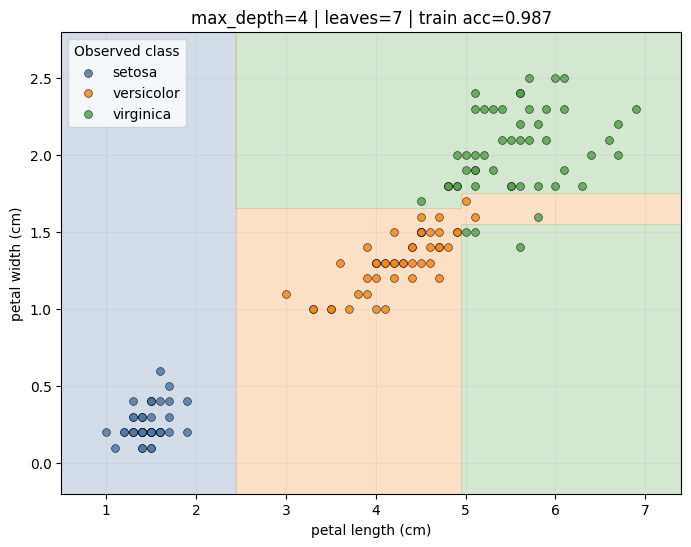

In [95]:
#| echo: false
plot_iris_decision_boundary(4)


## Iris boundary: max depth 5


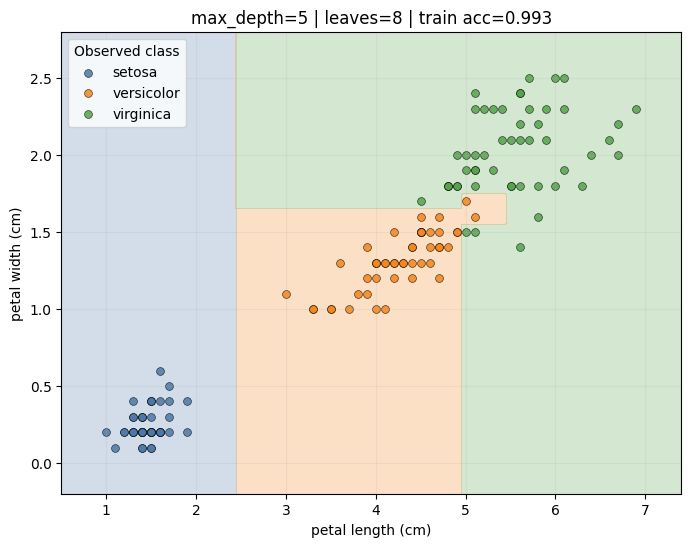

In [96]:
#| echo: false
plot_iris_decision_boundary(5)


### Iris checkpoint

- At depth 1, how many regions can the tree create?
- Which feature appears first in the shallow trees?
- Where does increasing depth help, and where does it start fitting small local details?

Keep these visual ideas in mind. The breast-cancer dataset has many more features, so the geometry is harder to draw, but the training mechanism is the same.

## 2. Load and inspect the breast-cancer dataset - 15 minutes

We use scikit-learn's Breast Cancer Wisconsin diagnostic dataset.

- **Rows:** observations
- **Predictors:** 30 numeric measurements
- **Target:** malignant or benign

The loader can return pandas objects directly with `as_frame=True`.

In [97]:
#| echo: false
#| output: false
dataset = load_breast_cancer(as_frame=True)

X = dataset.data.copy()
y = dataset.target.copy()

df = X.copy()
df["target"] = y
df["target_name"] = y.map(dict(enumerate(dataset.target_names)))


## Breast cancer: dataset dimensions


In [98]:
#| echo: false
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (569, 30)
Target shape: (569,)


## Breast cancer: data preview


In [99]:
#| echo: false
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


## Breast cancer: feature summary


In [100]:
#| echo: false
summary = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "n_unique": X.nunique(),
    "mean": X.mean(),
    "std": X.std(),
})
summary.head(10)

,dtype,missing,n_unique,mean,std
mean radius,float64,0,456,14.127292,3.524049
mean texture,float64,0,479,19.289649,4.301036
mean perimeter,float64,0,522,91.969033,24.298981
mean area,float64,0,539,654.889104,351.914129
mean smoothness,float64,0,474,0.096360,0.014064
mean compactness,float64,0,537,0.104341,0.052813
mean concavity,float64,0,537,0.088799,0.079720
mean concave points,float64,0,542,0.048919,0.038803
mean symmetry,float64,0,432,0.181162,0.027414
mean fractal dimension,float64,0,499,0.062798,0.007060


## Breast cancer: class counts


In [101]:
#| echo: false
df["target_name"].value_counts().to_frame("count")


,count
target_name,
benign,357
malignant,212


## Breast cancer: class proportions


In [102]:
#| echo: false
df["target_name"].value_counts(normalize=True).rename("proportion").to_frame()


,proportion
target_name,
benign,0.627417
malignant,0.372583


### Checkpoint

1. Is this a classification or regression task?
2. Is the target perfectly balanced?
3. Why do decision trees not require feature scaling?

<details>
<summary>Suggested answers</summary>

1. Binary classification.
2. No. The classes are moderately imbalanced.
3. Trees compare one feature with a threshold. Rescaling a feature preserves its ordering and therefore does not fundamentally change candidate partitions.
</details>

## 3. Create one fixed train/test split - 10 minutes

To compare depths and criteria fairly, every experiment must use the **same split**.

`stratify=y` keeps the class proportions similar in the training and test sets.

In [103]:
#| echo: false
#| output: false
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "train_count": y_train.value_counts().sort_index(),
    "test_count": y_test.value_counts().sort_index(),
})
split_summary.index = dataset.target_names


## Split: class balance


In [104]:
#| echo: false
display(split_summary)


,train_count,test_count
malignant,159,53
benign,267,90


## Split: matrix shapes


In [105]:
#| echo: false
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (426, 30)
Test shape: (143, 30)


## 4. Train the first decision tree - 15 minutes

Start with a **decision stump**, a tree with `max_depth=1`.

A depth-1 classifier makes one split and has at most two leaves.

## First tree: decision stump


In [106]:
#| echo: false
stump = DecisionTreeClassifier(
    max_depth=1,
    criterion="gini",
    random_state=RANDOM_STATE,
)
stump.fit(X_train, y_train)

train_pred = stump.predict(X_train)
test_pred = stump.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy: ", accuracy_score(y_test, test_pred))
print("Actual depth:  ", stump.get_depth())
print("Number of leaves:", stump.get_n_leaves())

Train accuracy: 0.9225352112676056
Test accuracy:  0.9230769230769231
Actual depth:   1
Number of leaves: 2


## Decision stump: tree view


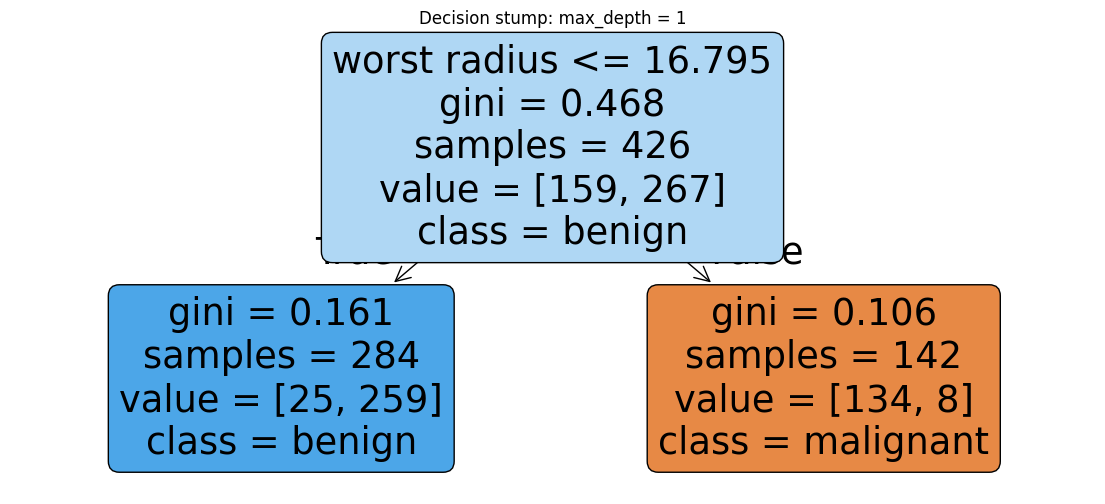

In [107]:
#| echo: false
plt.figure(figsize=(14, 6))
plot_tree(
    stump,
    feature_names=X.columns,
    class_names=dataset.target_names,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
)
plt.title("Decision stump: max_depth = 1")
plt.show()

## Decision stump: text rules


In [108]:
#| echo: false
print(export_text(stump, feature_names=list(X.columns)))

|--- worst radius <= 16.80
|   |--- class: 1
|--- worst radius >  16.80
|   |--- class: 0



## 5. Purity and impurity - 30 minutes

A node is **pure** when all its samples belong to one class.

### Gini impurity

For class proportions \(p_1,\dots,p_K\):

\[
G = 1 - \sum_{k=1}^{K}p_k^2
\]

For binary classification with positive-class proportion \(p\):

\[
G = 1 - p^2 - (1-p)^2 = 2p(1-p)
\]

### Entropy

\[
H = -\sum_{k=1}^{K}p_k\log_2(p_k)
\]

Both are:

- zero at a pure node,
- largest when the binary classes are evenly mixed,
- used to choose splits that reduce weighted child impurity.

In [109]:
#| echo: false
#| output: false
def gini_binary(p):
    p = np.asarray(p, dtype=float)
    return 1 - p**2 - (1 - p)**2

def entropy_binary(p):
    p = np.asarray(p, dtype=float)
    p_safe = np.clip(p, 1e-12, 1 - 1e-12)
    return -(p_safe * np.log2(p_safe) + (1 - p_safe) * np.log2(1 - p_safe))

p_grid = np.linspace(0, 1, 501)


## Impurity curves


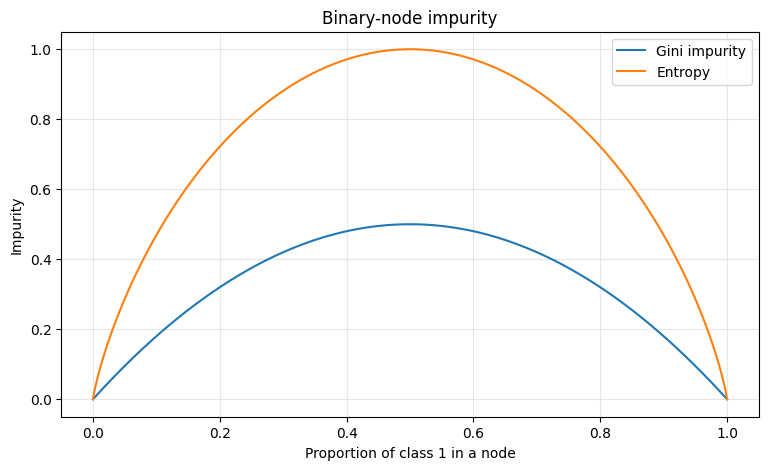

In [110]:
#| echo: false
plt.figure(figsize=(9, 5))
plt.plot(p_grid, gini_binary(p_grid), label="Gini impurity")
plt.plot(p_grid, entropy_binary(p_grid), label="Entropy")
plt.xlabel("Proportion of class 1 in a node")
plt.ylabel("Impurity")
plt.title("Binary-node impurity")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Exercise 1 — calculate impurity by hand (8 minutes)

A node contains 40 samples:

- 30 benign
- 10 malignant

Calculate:

1. Gini impurity.
2. Entropy.
3. Whether the node is more or less pure than a 20/20 node.

## Exercise: impurity by hand


In [111]:
#| echo: false
# Complete the calculation before revealing the solution.
n_benign = 30
n_malignant = 10
n_total = n_benign + n_malignant

p_benign = n_benign / n_total
p_malignant = n_malignant / n_total

gini = 1 - p_benign**2 - p_malignant**2
entropy = -(p_benign * np.log2(p_benign) + p_malignant * np.log2(p_malignant))

print("Gini:", gini)
print("Entropy:", entropy)

Gini: 0.375
Entropy: 0.8112781244591328


### Weighted impurity decrease

Suppose a parent node \(t\) is split into left and right children.

The local weighted reduction is:

\[
\Delta i(t)
=
i(t)
-
\frac{N_L}{N_t}i(t_L)
-
\frac{N_R}{N_t}i(t_R)
\]

scikit-learn's global contribution also weights by the fraction of all training samples reaching the node:

\[
\frac{N_t}{N}\Delta i(t)
\]

A good split has a large positive impurity decrease.

In [112]:
#| echo: false
#| output: false
def weighted_impurity_decrease(
    parent_impurity,
    left_impurity,
    right_impurity,
    n_parent,
    n_left,
    n_right,
):
    return (
        parent_impurity
        - (n_left / n_parent) * left_impurity
        - (n_right / n_parent) * right_impurity
    )


## Weighted impurity: numeric example


In [113]:
#| echo: false
example_decrease = weighted_impurity_decrease(
    parent_impurity=0.50,
    left_impurity=0.18,
    right_impurity=0.32,
    n_parent=100,
    n_left=60,
    n_right=40,
)
print("Local weighted impurity decrease:", example_decrease)


Local weighted impurity decrease: 0.264


## 6. Visualize the impact of tree levels - 40 minutes

We now fit trees with `max_depth` from 1 to 12.

For each depth, record:

- training accuracy,
- test accuracy,
- balanced test accuracy,
- test log loss,
- actual depth,
- number of leaves,
- node count,
- mean leaf impurity,
- weighted mean leaf impurity.

The model family remains exactly the same: one `DecisionTreeClassifier`.

In [114]:
#| echo: false
#| output: false
MAX_DEPTH = 12
depth_records = []
models_by_depth = {}

for depth in range(1, MAX_DEPTH + 1):
    model = DecisionTreeClassifier(
        max_depth=depth,
        criterion="gini",
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)
    models_by_depth[depth] = model

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_proba = model.predict_proba(X_test)

    tree = model.tree_
    leaf_mask = tree.children_left == tree.children_right
    leaf_impurities = tree.impurity[leaf_mask]
    leaf_samples = tree.weighted_n_node_samples[leaf_mask]

    depth_records.append({
        "max_depth": depth,
        "actual_depth": model.get_depth(),
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "test_log_loss": log_loss(y_test, test_proba),
        "n_leaves": model.get_n_leaves(),
        "node_count": tree.node_count,
        "mean_leaf_impurity": leaf_impurities.mean(),
        "weighted_leaf_impurity": np.average(leaf_impurities, weights=leaf_samples),
    })

depth_results = pd.DataFrame(depth_records)


## Depth sweep: metrics table


In [115]:
#| echo: false
display(depth_results.round(4))


,max_depth,actual_depth,train_accuracy,test_accuracy,test_balanced_accuracy,test_log_loss,n_leaves,node_count,mean_leaf_impurity,weighted_leaf_impurity
0,1,1,0.9225,0.9231,0.9079,0.2706,2,3,0.1334,0.1425
1,2,2,0.9577,0.9091,0.9161,0.4759,4,7,0.1313,0.0661
2,3,3,0.9765,0.9441,0.9362,0.8763,7,13,0.1512,0.0386
3,4,4,0.9883,0.9441,0.9400,1.3539,11,21,0.0923,0.0202
4,5,5,0.9953,0.9371,0.9345,1.8494,15,29,0.0255,0.0082
5,6,6,0.9977,0.9371,0.9345,2.2693,17,33,0.0062,0.0044
6,7,7,1.0000,0.9231,0.9234,2.7726,18,35,0.0000,0.0000
7,8,7,1.0000,0.9231,0.9234,2.7726,18,35,0.0000,0.0000
8,9,7,1.0000,0.9231,0.9234,2.7726,18,35,0.0000,0.0000
9,10,7,1.0000,0.9231,0.9234,2.7726,18,35,0.0000,0.0000


## Accuracy by depth


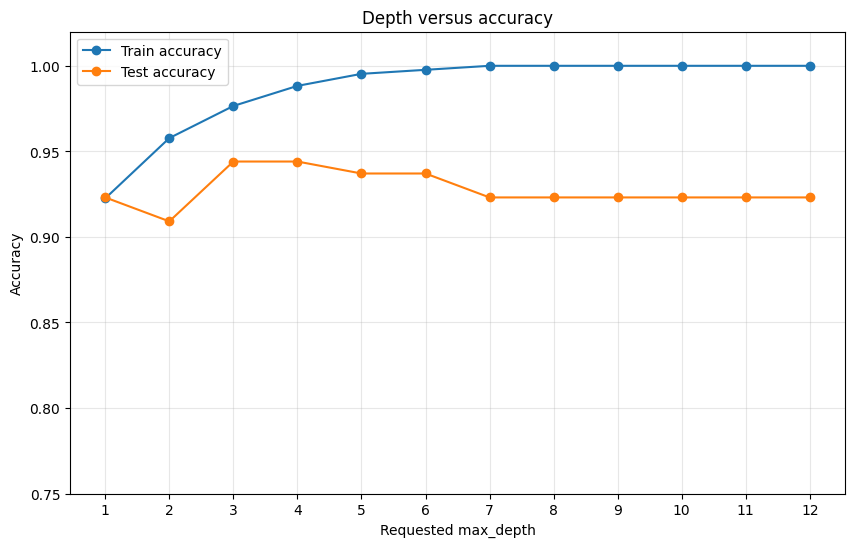

In [116]:
#| echo: false
plt.figure(figsize=(10, 6))
plt.plot(
    depth_results["max_depth"],
    depth_results["train_accuracy"],
    marker="o",
    label="Train accuracy",
)
plt.plot(
    depth_results["max_depth"],
    depth_results["test_accuracy"],
    marker="o",
    label="Test accuracy",
)
plt.xlabel("Requested max_depth")
plt.ylabel("Accuracy")
plt.title("Depth versus accuracy")
plt.xticks(depth_results["max_depth"])
plt.ylim(0.75, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Log loss by depth


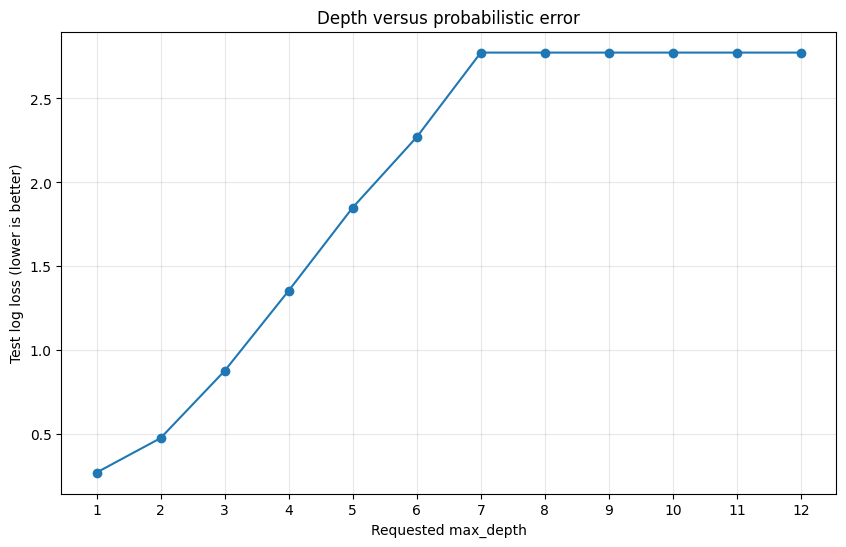

In [117]:
#| echo: false
plt.figure(figsize=(10, 6))
plt.plot(
    depth_results["max_depth"],
    depth_results["test_log_loss"],
    marker="o",
)
plt.xlabel("Requested max_depth")
plt.ylabel("Test log loss (lower is better)")
plt.title("Depth versus probabilistic error")
plt.xticks(depth_results["max_depth"])
plt.grid(alpha=0.3)
plt.show()

## Leaf impurity by depth


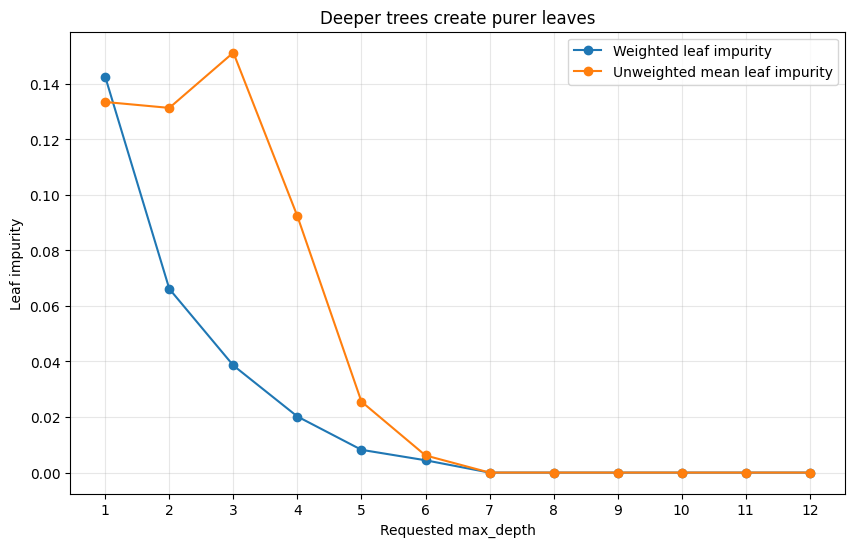

In [118]:
#| echo: false
plt.figure(figsize=(10, 6))
plt.plot(
    depth_results["max_depth"],
    depth_results["weighted_leaf_impurity"],
    marker="o",
    label="Weighted leaf impurity",
)
plt.plot(
    depth_results["max_depth"],
    depth_results["mean_leaf_impurity"],
    marker="o",
    label="Unweighted mean leaf impurity",
)
plt.xlabel("Requested max_depth")
plt.ylabel("Leaf impurity")
plt.title("Deeper trees create purer leaves")
plt.xticks(depth_results["max_depth"])
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Model complexity by depth


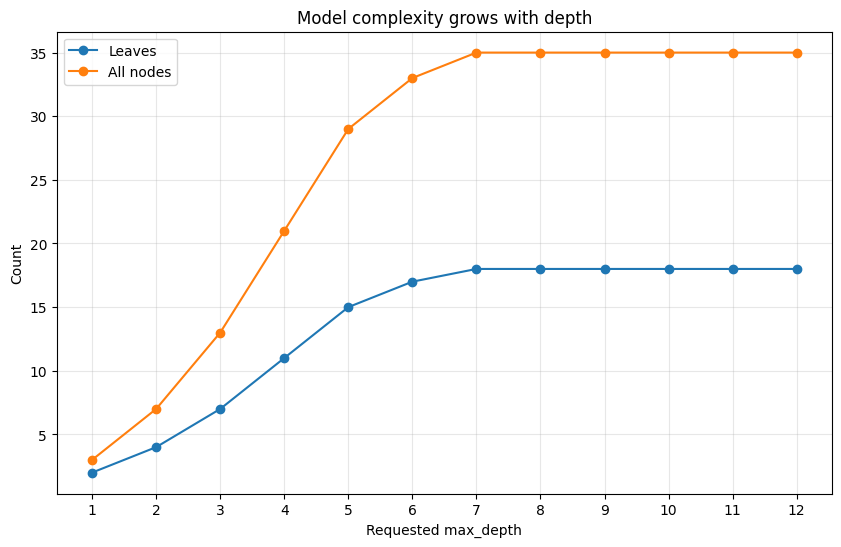

In [119]:
#| echo: false
plt.figure(figsize=(10, 6))
plt.plot(
    depth_results["max_depth"],
    depth_results["n_leaves"],
    marker="o",
    label="Leaves",
)
plt.plot(
    depth_results["max_depth"],
    depth_results["node_count"],
    marker="o",
    label="All nodes",
)
plt.xlabel("Requested max_depth")
plt.ylabel("Count")
plt.title("Model complexity grows with depth")
plt.xticks(depth_results["max_depth"])
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Interpretation questions

1. At which depth is test accuracy highest?
2. Does the depth with the purest leaves necessarily generalize best?
3. At what depth does training accuracy reach 1.0?
4. Why can test log loss worsen sharply even when accuracy changes little?
5. Where do you see evidence of overfitting?

In [120]:
#| echo: false
#| output: false
best_depth_row = depth_results.loc[depth_results["test_accuracy"].idxmax()]
perfect_train = depth_results.loc[
    depth_results["train_accuracy"] == 1.0, "max_depth"
]


## Best test depth


In [121]:
#| echo: false
display(best_depth_row.to_frame("value"))


,value
max_depth,3.000000
actual_depth,3.000000
train_accuracy,0.976526
test_accuracy,0.944056
test_balanced_accuracy,0.936164
test_log_loss,0.876332
n_leaves,7.000000
node_count,13.000000
mean_leaf_impurity,0.151231
weighted_leaf_impurity,0.038564


## First perfect training depth


In [122]:
#| echo: false
if len(perfect_train):
    print("First depth with perfect training accuracy:", int(perfect_train.iloc[0]))
else:
    print("No tested depth achieved perfect training accuracy.")


First depth with perfect training accuracy: 7


### View selected tree structures

Plotting every deep tree becomes unreadable. Compare depths 1, 2, 3, and 5.

## Tree structure: max depth 1


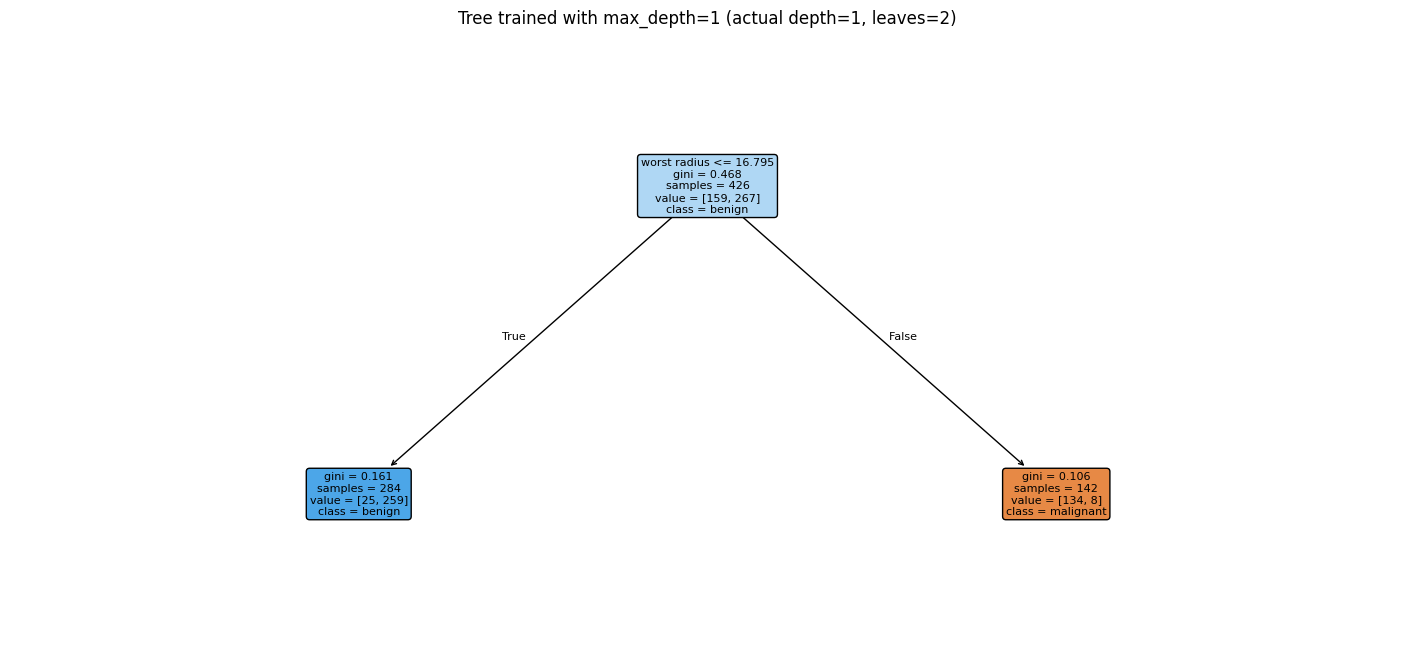

In [123]:
#| echo: false
depth = 1
model = models_by_depth[depth]
plt.figure(figsize=(18, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=dataset.target_names,
    filled=True,
    rounded=True,
    impurity=True,
    max_depth=depth,
    fontsize=8,
)
plt.title(
    f"Tree trained with max_depth={depth} "
    f"(actual depth={model.get_depth()}, leaves={model.get_n_leaves()})"
)
plt.show()


## Tree structure: max depth 2


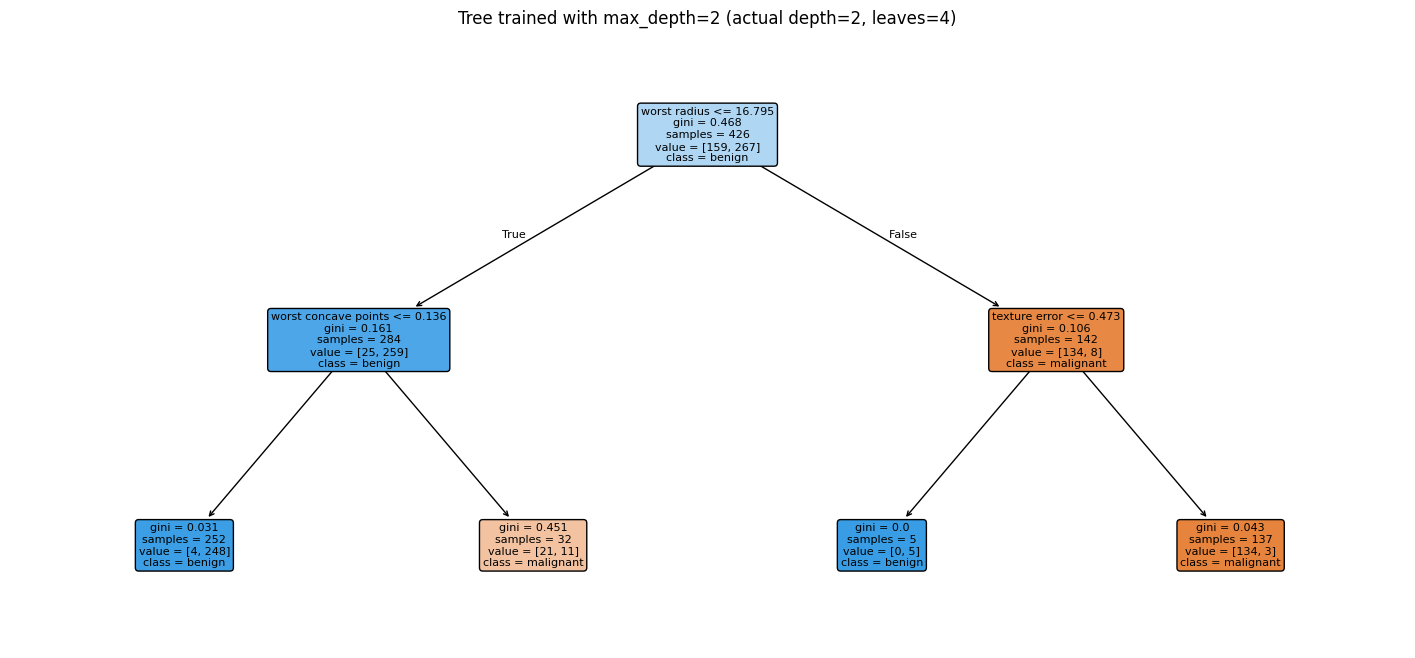

In [124]:
#| echo: false
depth = 2
model = models_by_depth[depth]
plt.figure(figsize=(18, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=dataset.target_names,
    filled=True,
    rounded=True,
    impurity=True,
    max_depth=depth,
    fontsize=8,
)
plt.title(
    f"Tree trained with max_depth={depth} "
    f"(actual depth={model.get_depth()}, leaves={model.get_n_leaves()})"
)
plt.show()


## Tree structure: max depth 3


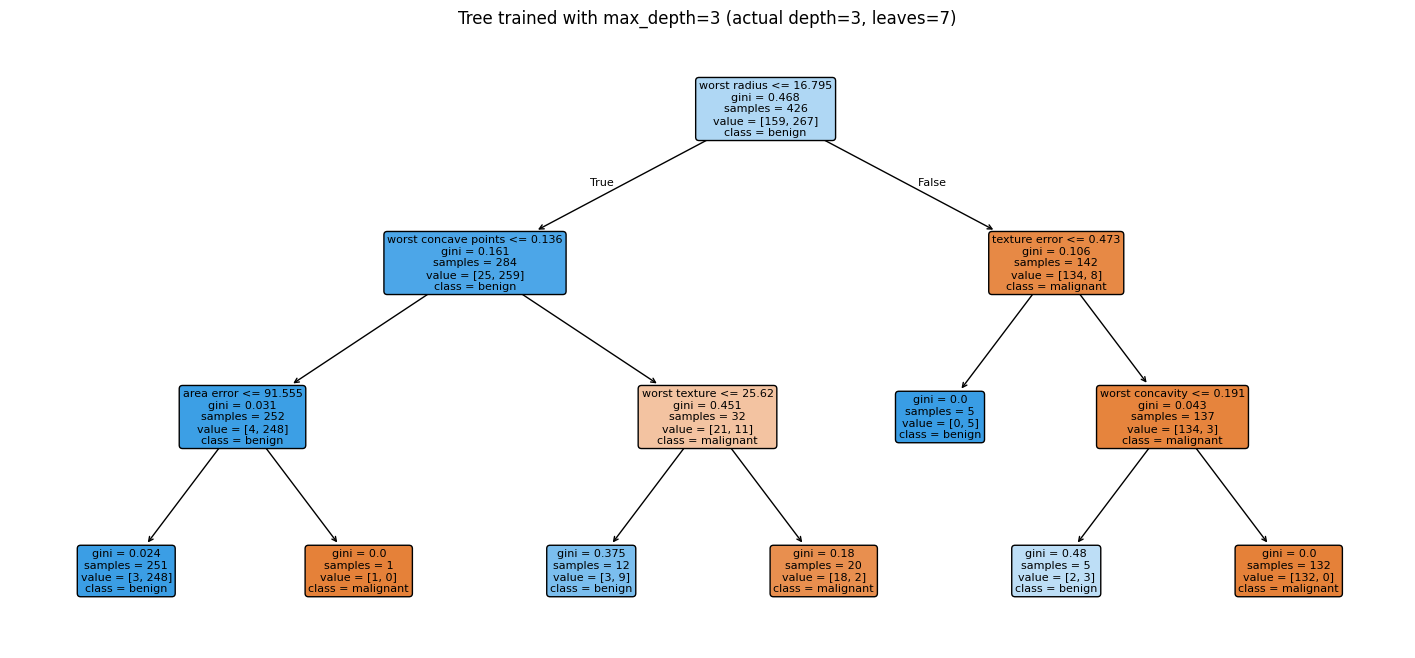

In [125]:
#| echo: false
depth = 3
model = models_by_depth[depth]
plt.figure(figsize=(18, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=dataset.target_names,
    filled=True,
    rounded=True,
    impurity=True,
    max_depth=depth,
    fontsize=8,
)
plt.title(
    f"Tree trained with max_depth={depth} "
    f"(actual depth={model.get_depth()}, leaves={model.get_n_leaves()})"
)
plt.show()


## Tree structure: max depth 5


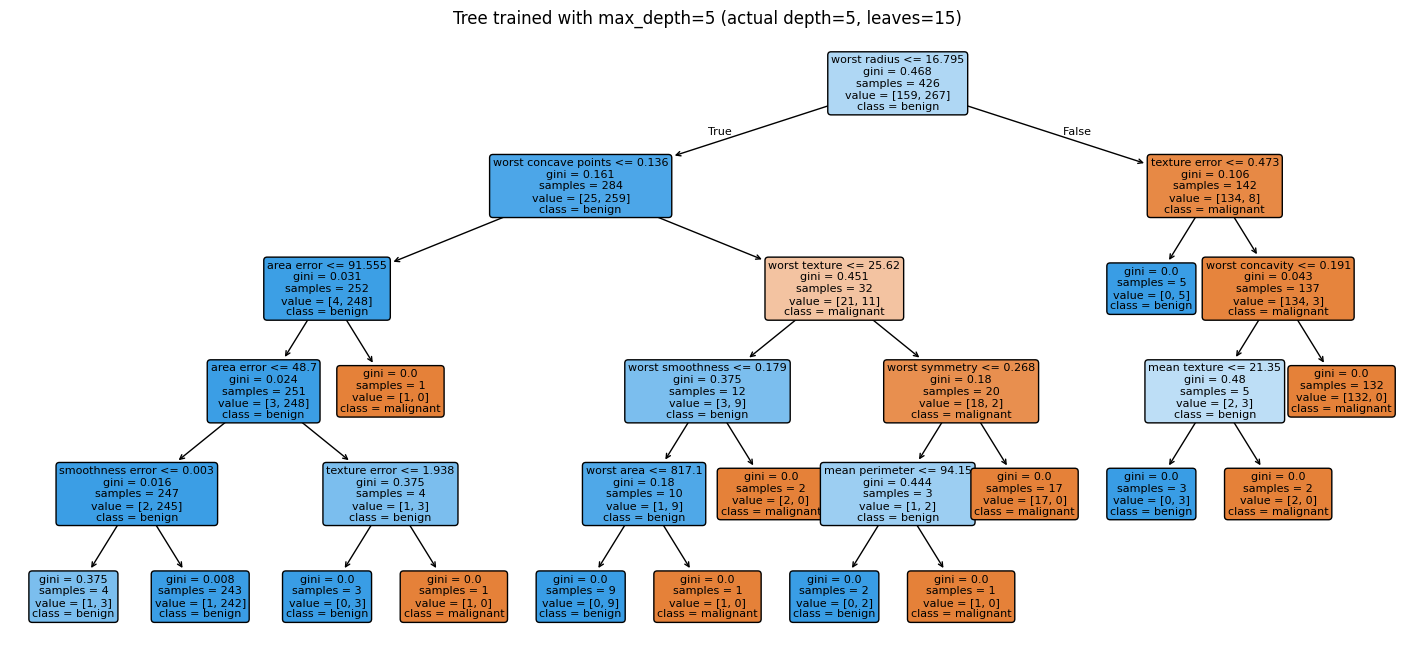

In [126]:
#| echo: false
depth = 5
model = models_by_depth[depth]
plt.figure(figsize=(18, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=dataset.target_names,
    filled=True,
    rounded=True,
    impurity=True,
    max_depth=depth,
    fontsize=8,
)
plt.title(
    f"Tree trained with max_depth={depth} "
    f"(actual depth={model.get_depth()}, leaves={model.get_n_leaves()})"
)
plt.show()


### Exercise 2 — choose a depth (10 minutes)

Choose a depth for a hypothetical interpretable screening aid.

Your answer must mention:

- test performance,
- train/test gap,
- number of leaves,
- readability,
- why maximum purity is not the only objective.

Write your reasoning below.

## Exercise: choose a depth


In [127]:
#| echo: false
chosen_depth = 3  # Change this after inspecting the charts.
display(
    depth_results.loc[
        depth_results["max_depth"] == chosen_depth
    ].T.rename(columns={chosen_depth - 1: "selected_model"})
)

,selected_model
max_depth,3.000000
actual_depth,3.000000
train_accuracy,0.976526
test_accuracy,0.944056
test_balanced_accuracy,0.936164
test_log_loss,0.876332
n_leaves,7.000000
node_count,13.000000
mean_leaf_impurity,0.151231
weighted_leaf_impurity,0.038564


## 7. How impurity-based feature importance is calculated - 40 minutes

For one tree, each split node contributes importance to the feature used at that node.

For split node \(t\), the unnormalized contribution is:

\[
N_t i(t) - N_L i(t_L) - N_R i(t_R)
\]

where:

- \(N_t\) is the weighted number of samples at the parent,
- \(i(t)\) is parent impurity,
- \(N_L, N_R\) and \(i(t_L), i(t_R)\) refer to the children.

Contributions are summed by feature and then normalized so all importances sum to 1.

Therefore, a feature is important when it:

1. is used in one or more splits,
2. affects many training samples,
3. creates a large impurity reduction.

A feature not chosen for a split gets zero impurity-based importance.

In [128]:
#| echo: false
#| output: false
importance_depth = 4
importance_model = models_by_depth[importance_depth]

sklearn_importance = pd.Series(
    importance_model.feature_importances_,
    index=X.columns,
    name="sklearn_importance",
).sort_values(ascending=False)


## Top feature importances


In [129]:
#| echo: false
display(sklearn_importance.head(12).to_frame())


,sklearn_importance
worst radius,0.726829
worst concave points,0.122113
texture error,0.048398
worst texture,0.033231
worst concavity,0.018188
mean concave points,0.014158
area error,0.012613
mean texture,0.012585
worst symmetry,0.011885
mean area,0.000000


## Feature importance sum


In [130]:
#| echo: false
print("Sum:", sklearn_importance.sum())


Sum: 1.0


In [131]:
#| echo: false
#| output: false
def manual_mdi_importance(fitted_tree, feature_names):
    tree = fitted_tree.tree_
    contributions = np.zeros(fitted_tree.n_features_in_, dtype=float)

    for node_id in range(tree.node_count):
        feature_id = tree.feature[node_id]

        # Leaf nodes have feature_id == -2.
        if feature_id < 0:
            continue

        left_id = tree.children_left[node_id]
        right_id = tree.children_right[node_id]

        parent_term = (
            tree.weighted_n_node_samples[node_id]
            * tree.impurity[node_id]
        )
        left_term = (
            tree.weighted_n_node_samples[left_id]
            * tree.impurity[left_id]
        )
        right_term = (
            tree.weighted_n_node_samples[right_id]
            * tree.impurity[right_id]
        )

        contributions[feature_id] += parent_term - left_term - right_term

    total = contributions.sum()
    normalized = contributions / total if total > 0 else contributions

    return pd.Series(
        normalized,
        index=feature_names,
        name="manual_importance",
    )

manual_importance = manual_mdi_importance(
    importance_model,
    X.columns,
)

importance_check = pd.concat(
    [
        pd.Series(
            importance_model.feature_importances_,
            index=X.columns,
            name="sklearn_importance",
        ),
        manual_importance,
    ],
    axis=1,
)
importance_check["absolute_difference"] = (
    importance_check["sklearn_importance"]
    - importance_check["manual_importance"]
).abs()


## Manual importance equals scikit-learn


In [132]:
#| echo: false
display(importance_check.sort_values("sklearn_importance", ascending=False).head(12))


,sklearn_importance,manual_importance,absolute_difference
worst radius,0.726829,0.726829,1.110223e-16
worst concave points,0.122113,0.122113,0.000000e+00
texture error,0.048398,0.048398,0.000000e+00
worst texture,0.033231,0.033231,0.000000e+00
worst concavity,0.018188,0.018188,0.000000e+00
mean concave points,0.014158,0.014158,1.734723e-18
area error,0.012613,0.012613,1.734723e-18
mean texture,0.012585,0.012585,0.000000e+00
worst symmetry,0.011885,0.011885,0.000000e+00
mean area,0.000000,0.000000,0.000000e+00


## Manual importance: numerical difference


In [133]:
#| echo: false
print("Maximum absolute difference:", importance_check["absolute_difference"].max())


Maximum absolute difference: 1.1102230246251565e-16


### Inspect each split's contribution

The following table exposes the tree's internal arrays and computes the impurity decrease contributed by each split node.

In [134]:
#| echo: false
#| output: false
def split_contribution_table(fitted_tree, feature_names):
    tree = fitted_tree.tree_
    rows = []

    for node_id in range(tree.node_count):
        feature_id = tree.feature[node_id]
        if feature_id < 0:
            continue

        left_id = tree.children_left[node_id]
        right_id = tree.children_right[node_id]

        parent_weighted_impurity = (
            tree.weighted_n_node_samples[node_id] * tree.impurity[node_id]
        )
        children_weighted_impurity = (
            tree.weighted_n_node_samples[left_id] * tree.impurity[left_id]
            + tree.weighted_n_node_samples[right_id] * tree.impurity[right_id]
        )
        contribution = parent_weighted_impurity - children_weighted_impurity

        rows.append({
            "node": node_id,
            "feature": feature_names[feature_id],
            "threshold": tree.threshold[node_id],
            "samples_at_node": tree.n_node_samples[node_id],
            "parent_impurity": tree.impurity[node_id],
            "left_impurity": tree.impurity[left_id],
            "right_impurity": tree.impurity[right_id],
            "unnormalized_contribution": contribution,
        })

    result = pd.DataFrame(rows)
    result["normalized_node_contribution"] = (
        result["unnormalized_contribution"]
        / result["unnormalized_contribution"].sum()
    )
    return result.sort_values(
        "normalized_node_contribution",
        ascending=False,
    )

split_details = split_contribution_table(
    importance_model,
    list(X.columns),
)


## Split contribution details


In [135]:
#| echo: false
display(split_details.round(5))


,node,feature,threshold,samples_at_node,parent_impurity,left_impurity,right_impurity,unnormalized_contribution,normalized_node_contribution
0,0,worst radius,16.79500,426,0.46786,0.16056,0.10633,138.61268,0.72683
1,1,worst concave points,0.13595,284,0.16056,0.03124,0.45117,23.28808,0.12211
7,14,texture error,0.47315,142,0.10633,0.00000,0.04284,9.22998,0.04840
4,7,worst texture,25.62000,32,0.45117,0.37500,0.18000,6.33750,0.03323
8,16,worst concavity,0.19070,137,0.04284,0.48000,0.00000,3.46861,0.01819
5,8,mean concave points,0.07973,12,0.37500,0.18000,0.00000,2.70000,0.01416
9,17,mean texture,21.35000,5,0.48000,0.00000,0.00000,2.40000,0.01258
6,11,worst symmetry,0.26820,20,0.18000,0.44444,0.00000,2.26667,0.01189
2,2,area error,91.55500,252,0.03124,0.02362,0.00000,1.94473,0.01020
3,3,area error,48.70000,251,0.02362,0.01606,0.37500,0.46068,0.00242


## Top split contributions


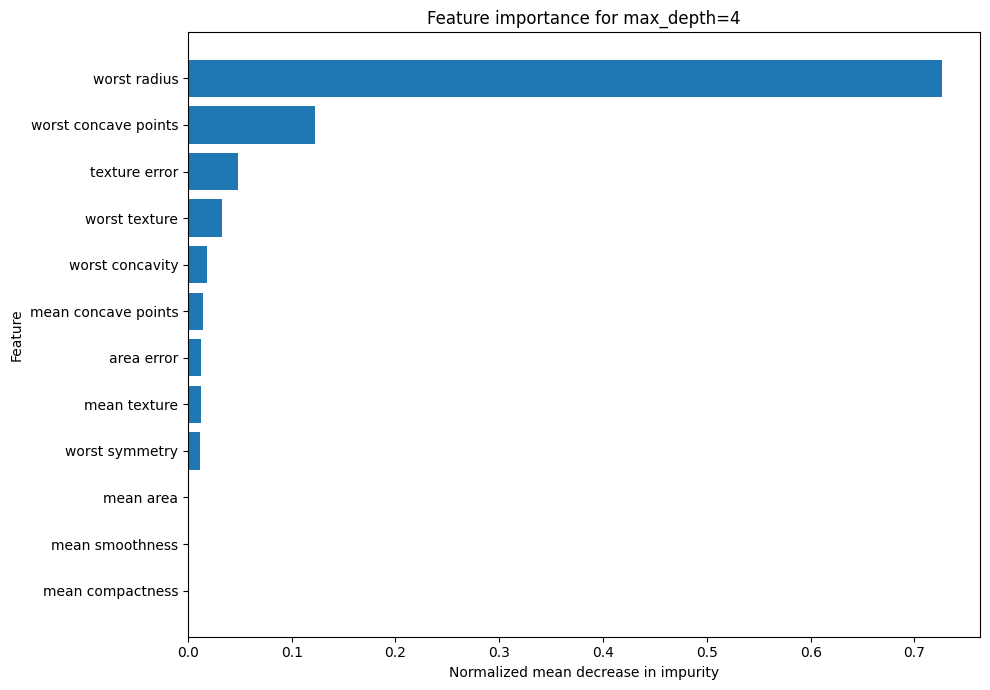

In [136]:
#| echo: false
top_n = 12
top_importances = sklearn_importance.head(top_n).sort_values()

plt.figure(figsize=(10, 7))
plt.barh(top_importances.index, top_importances.values)
plt.xlabel("Normalized mean decrease in impurity")
plt.ylabel("Feature")
plt.title(f"Feature importance for max_depth={importance_depth}")
plt.tight_layout()
plt.show()

### Feature importance changes with depth

Feature importance is a property of the **fitted tree**, not an eternal property of the dataset.

We now place the importances from each depth in a pandas table.

## Feature importance over depth


In [137]:
#| echo: false
importance_by_depth = pd.DataFrame(
    {
        depth: pd.Series(
            model.feature_importances_,
            index=X.columns,
        )
        for depth, model in models_by_depth.items()
    }
)
importance_by_depth.columns.name = "max_depth"

top_features_overall = (
    importance_by_depth.max(axis=1)
    .sort_values(ascending=False)
    .head(12)
    .index
)

display(
    importance_by_depth.loc[top_features_overall]
    .round(3)
)

max_depth,1,2,3,4,5,6,7,8,9,10,11,12
worst radius,1.0,0.810,0.758,0.727,0.708,0.709,0.695,0.695,0.695,0.695,0.695,0.695
worst concave points,0.0,0.136,0.127,0.122,0.119,0.127,0.117,0.117,0.117,0.117,0.117,0.117
worst texture,0.0,0.000,0.035,0.033,0.032,0.040,0.061,0.061,0.061,0.061,0.061,0.061
texture error,0.0,0.054,0.050,0.048,0.055,0.054,0.046,0.046,0.046,0.046,0.046,0.046
worst concavity,0.0,0.000,0.019,0.018,0.018,0.018,0.017,0.017,0.017,0.017,0.017,0.017
mean concave points,0.0,0.000,0.000,0.014,0.000,0.014,0.014,0.014,0.014,0.014,0.014,0.014
worst smoothness,0.0,0.000,0.000,0.000,0.014,0.000,0.000,0.000,0.000,0.000,0.000,0.000
area error,0.0,0.000,0.011,0.013,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.012
mean texture,0.0,0.000,0.000,0.013,0.012,0.012,0.000,0.000,0.000,0.000,0.000,0.000
worst symmetry,0.0,0.000,0.000,0.012,0.012,0.011,0.011,0.011,0.011,0.011,0.011,0.011


## Feature importance heatmap


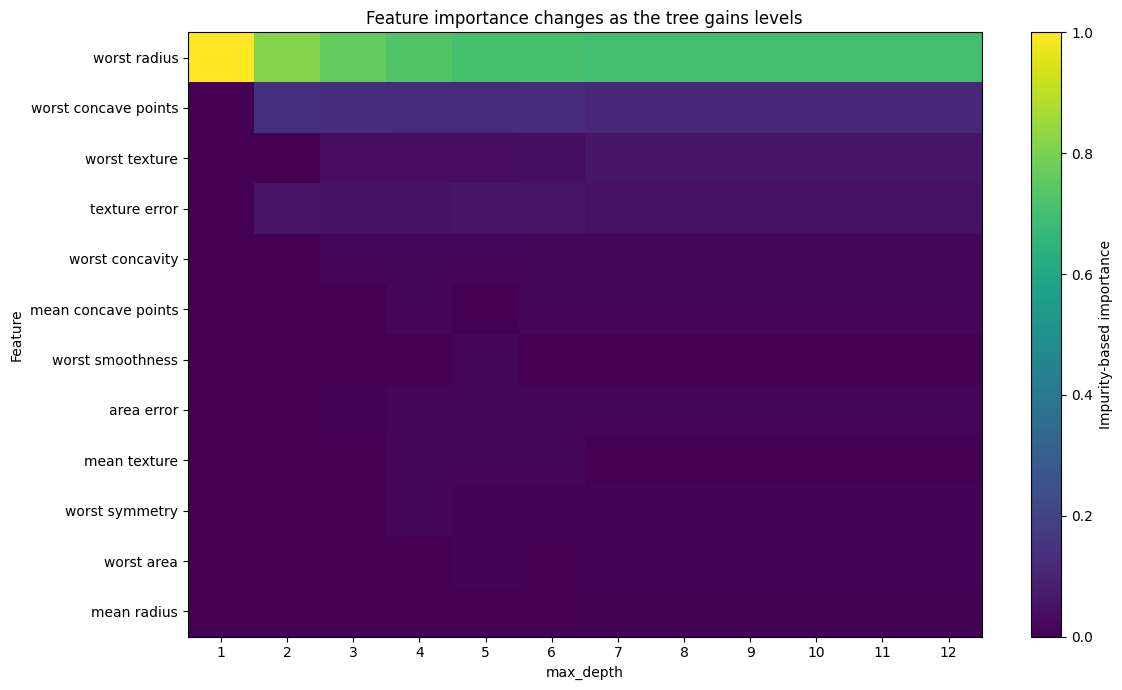

In [138]:
#| echo: false
heatmap_data = importance_by_depth.loc[top_features_overall]

plt.figure(figsize=(12, 7))
image = plt.imshow(heatmap_data.values, aspect="auto")
plt.colorbar(image, label="Impurity-based importance")
plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
)
plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index,
)
plt.xlabel("max_depth")
plt.ylabel("Feature")
plt.title("Feature importance changes as the tree gains levels")
plt.tight_layout()
plt.show()

### Important caveats

Impurity-based feature importance:

- is calculated from the **training tree**;
- can distribute importance unpredictably among correlated predictors;
- can favor features that offer many possible split points;
- does not state the direction of an effect;
- is not causal;
- can change with depth, criterion, split, or random seed.

In this lab we stay focused on tree-native impurity importance rather than introducing another model or importance algorithm.

### Exercise 3 — explain zero importance (8 minutes)

Find three features with zero importance at depth 2.

For each one, answer:

- Does zero mean the feature contains no predictive information?
- Or does it mean the fitted tree did not select it?

## Exercise: zero importance


In [139]:
#| echo: false
depth_for_zero_check = 2
zero_importance_features = (
    pd.Series(
        models_by_depth[depth_for_zero_check].feature_importances_,
        index=X.columns,
    )
    .loc[lambda s: s == 0]
    .index
    .tolist()
)

print(f"Number of zero-importance features at depth {depth_for_zero_check}:",
      len(zero_importance_features))
print(zero_importance_features[:10])

Number of zero-importance features at depth 2: 27
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension']


## 8. Compare purity criteria - 35 minutes

`DecisionTreeClassifier` currently supports:

- `"gini"`
- `"entropy"`
- `"log_loss"`

For classification trees, these criteria evaluate candidate splits using class purity. We compare them while holding all other settings fixed.

In [140]:
#| echo: false
#| output: false
criteria = ["gini", "entropy", "log_loss"]
criterion_depth_records = []
criterion_models = {}

def fit_criterion_depth(criterion, depth):
    model = DecisionTreeClassifier(
        max_depth=depth,
        criterion=criterion,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)
    criterion_models[(criterion, depth)] = model

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_proba = model.predict_proba(X_test)

    criterion_depth_records.append({
        "criterion": criterion,
        "max_depth": depth,
        "actual_depth": model.get_depth(),
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "test_log_loss": log_loss(y_test, test_proba),
        "n_leaves": model.get_n_leaves(),
        "node_count": model.tree_.node_count,
    })

for criterion in criteria:
    for depth in range(1, MAX_DEPTH + 1):
        fit_criterion_depth(criterion, depth)

criterion_results = pd.DataFrame(criterion_depth_records)


## Criteria comparison: first rows


In [141]:
#| echo: false
display(criterion_results.head(12).round(4))


,criterion,max_depth,actual_depth,train_accuracy,test_accuracy,test_balanced_accuracy,test_log_loss,n_leaves,node_count
0,gini,1,1,0.9225,0.9231,0.9079,0.2706,2,3
1,gini,2,2,0.9577,0.9091,0.9161,0.4759,4,7
2,gini,3,3,0.9765,0.9441,0.9362,0.8763,7,13
3,gini,4,4,0.9883,0.9441,0.9400,1.3539,11,21
4,gini,5,5,0.9953,0.9371,0.9345,1.8494,15,29
5,gini,6,6,0.9977,0.9371,0.9345,2.2693,17,33
6,gini,7,7,1.0000,0.9231,0.9234,2.7726,18,35
7,gini,8,7,1.0000,0.9231,0.9234,2.7726,18,35
8,gini,9,7,1.0000,0.9231,0.9234,2.7726,18,35
9,gini,10,7,1.0000,0.9231,0.9234,2.7726,18,35


In [142]:
#| echo: false
#| output: false
def plot_criterion_metric(metric, ylabel, title, ylim=None):
    plt.figure(figsize=(10, 6))
    for criterion in criteria:
        subset = criterion_results[
            criterion_results["criterion"] == criterion
        ]
        plt.plot(
            subset["max_depth"],
            subset[metric],
            marker="o",
            label=criterion,
        )

    plt.xlabel("max_depth")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(range(1, MAX_DEPTH + 1))
    if ylim is not None:
        plt.ylim(*ylim)
    plt.grid(alpha=0.3)
    plt.legend(title="criterion")
    plt.show()


## Criteria accuracy chart


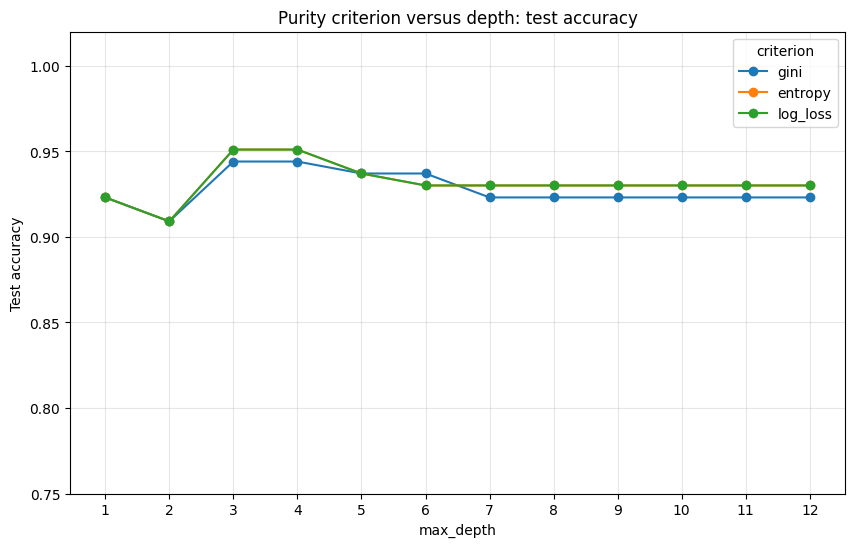

In [143]:
#| echo: false
plot_criterion_metric(
    metric="test_accuracy",
    ylabel="Test accuracy",
    title="Purity criterion versus depth: test accuracy",
    ylim=(0.75, 1.02),
)


## Criteria log-loss chart


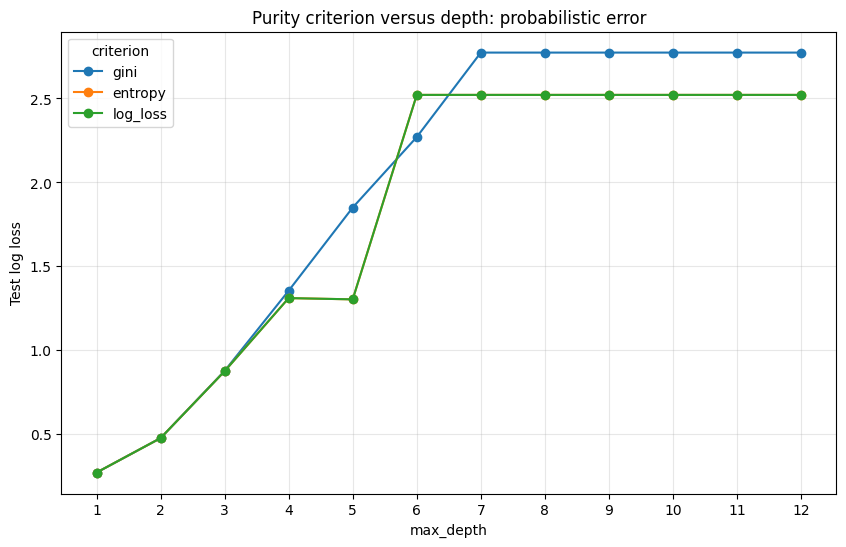

In [144]:
#| echo: false
plot_criterion_metric(
    metric="test_log_loss",
    ylabel="Test log loss",
    title="Purity criterion versus depth: probabilistic error",
)


## Fixed-depth criteria models


In [145]:
#| echo: false
fixed_depth = 3

criterion_summary = (
    criterion_results[
        criterion_results["max_depth"] == fixed_depth
    ]
    .set_index("criterion")
    .sort_values("test_accuracy", ascending=False)
)
display(criterion_summary.round(4))

,max_depth,actual_depth,train_accuracy,test_accuracy,test_balanced_accuracy,test_log_loss,n_leaves,node_count
criterion,,,,,,,,
entropy,3,3,0.9671,0.9510,0.9417,0.8744,7,13
log_loss,3,3,0.9671,0.9510,0.9417,0.8744,7,13
gini,3,3,0.9765,0.9441,0.9362,0.8763,7,13


### Compare the learned root split

Even when final scores are similar, criteria may select different features or thresholds.

In [146]:
#| echo: false
#| output: false
root_rows = []

def add_root_row(criterion):
    model = criterion_models[(criterion, fixed_depth)]
    root_feature_id = model.tree_.feature[0]

    root_rows.append({
        "criterion": criterion,
        "root_feature": X.columns[root_feature_id],
        "root_threshold": model.tree_.threshold[0],
        "root_impurity": model.tree_.impurity[0],
        "actual_depth": model.get_depth(),
        "n_leaves": model.get_n_leaves(),
    })

for criterion in criteria:
    add_root_row(criterion)

root_comparison = pd.DataFrame(root_rows).set_index("criterion")


## Criteria root split table


In [147]:
#| echo: false
display(root_comparison)


,root_feature,root_threshold,root_impurity,actual_depth,n_leaves
criterion,,,,,
gini,worst radius,16.795,0.467864,3,7
entropy,worst radius,16.795,0.953127,3,7
log_loss,worst radius,16.795,0.953127,3,7


## Root rules: gini


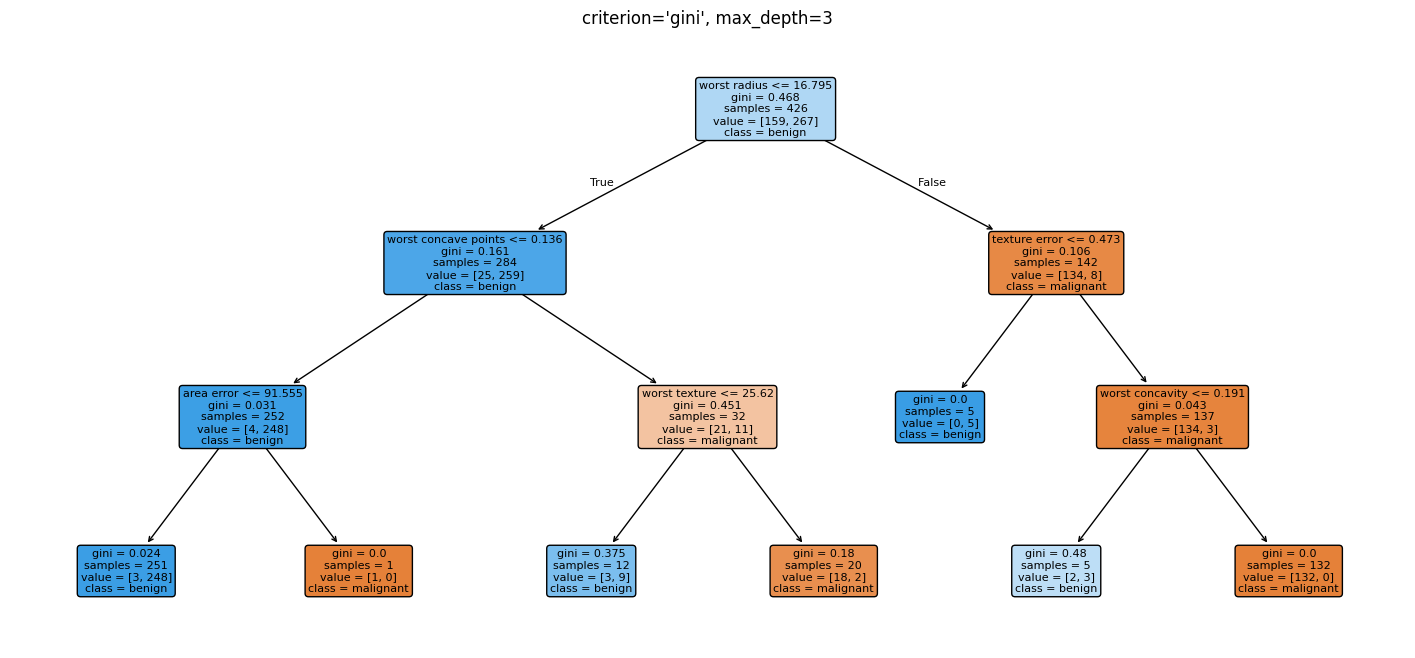

In [148]:
#| echo: false
criterion = "gini"
model = criterion_models[(criterion, fixed_depth)]
plt.figure(figsize=(18, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=dataset.target_names,
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=8,
)
plt.title(f"criterion='{criterion}', max_depth={fixed_depth}")
plt.show()


## Root rules: entropy


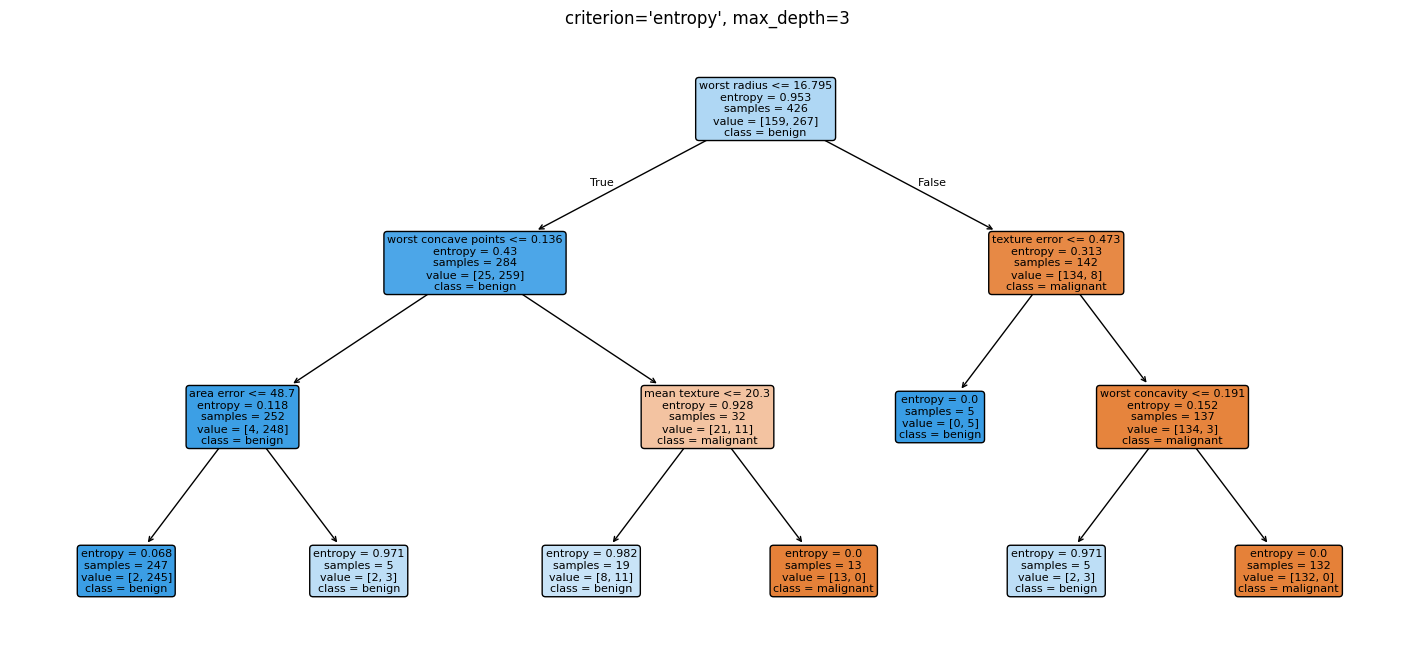

In [149]:
#| echo: false
criterion = "entropy"
model = criterion_models[(criterion, fixed_depth)]
plt.figure(figsize=(18, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=dataset.target_names,
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=8,
)
plt.title(f"criterion='{criterion}', max_depth={fixed_depth}")
plt.show()


## Root rules: log_loss


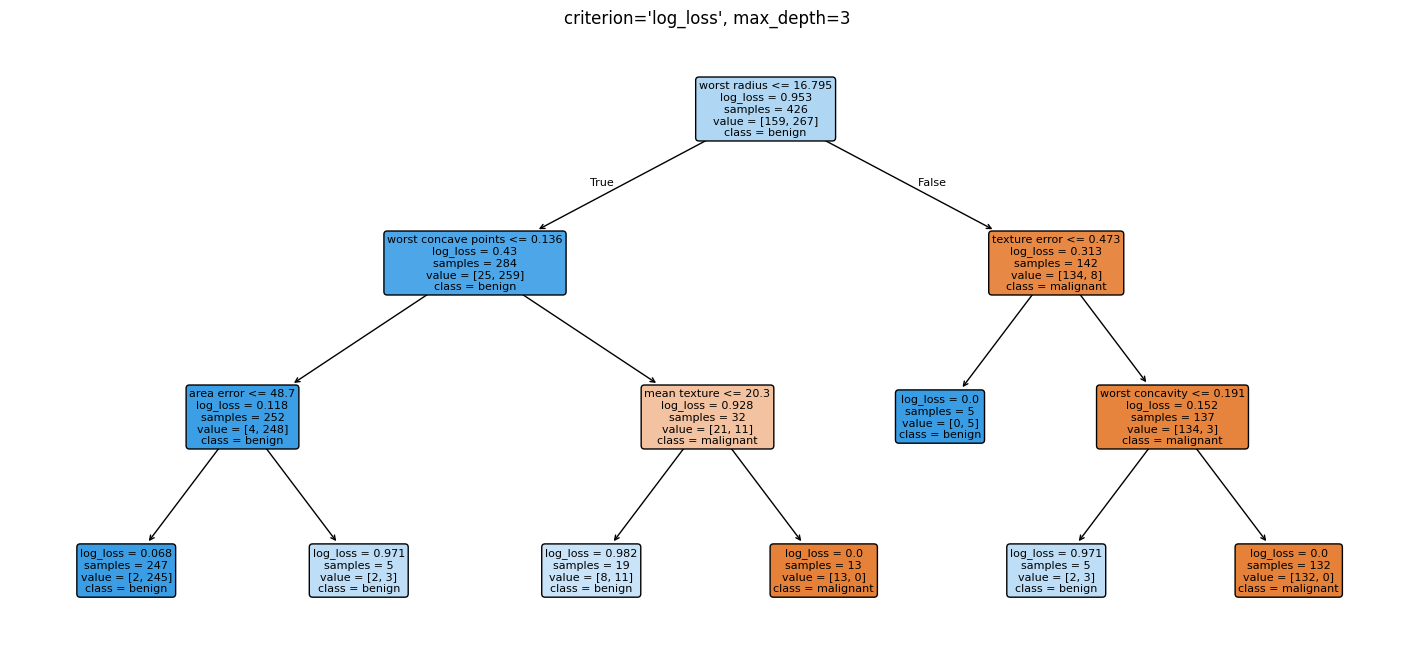

In [150]:
#| echo: false
criterion = "log_loss"
model = criterion_models[(criterion, fixed_depth)]
plt.figure(figsize=(18, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=dataset.target_names,
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=8,
)
plt.title(f"criterion='{criterion}', max_depth={fixed_depth}")
plt.show()


### Compare feature importance across criteria

Keep depth fixed so the comparison isolates the split criterion as much as possible.

In [151]:
#| echo: false
#| output: false
def criterion_feature_importance(criterion):
    return pd.Series(
        criterion_models[(criterion, fixed_depth)].feature_importances_,
        index=X.columns,
    )

criterion_importance = pd.DataFrame(
    {
        criterion: criterion_feature_importance(criterion)
        for criterion in criteria
    }
)

top_criterion_features = (
    criterion_importance.max(axis=1)
    .sort_values(ascending=False)
    .head(12)
    .index
)


## Criteria feature-importance table


In [152]:
#| echo: false
display(
    criterion_importance.loc[top_criterion_features]
    .sort_values("gini", ascending=False)
    .round(4)
)


,gini,entropy,log_loss
worst radius,0.7579,0.6638,0.6638
worst concave points,0.1273,0.1738,0.1738
texture error,0.0505,0.0654,0.0654
worst texture,0.0347,0.0000,0.0000
worst concavity,0.0190,0.0442,0.0442
area error,0.0106,0.0222,0.0222
mean texture,0.0000,0.0306,0.0306
mean smoothness,0.0000,0.0000,0.0000
mean concavity,0.0000,0.0000,0.0000
mean concave points,0.0000,0.0000,0.0000


In [153]:
#| echo: false
#| output: false
def plot_criterion_importance():
    plot_data = criterion_importance.loc[top_criterion_features]
    x_positions = np.arange(len(plot_data.index))
    bar_width = 0.25

    plt.figure(figsize=(14, 7))
    for offset, criterion in enumerate(criteria):
        plt.bar(
            x_positions + (offset - 1) * bar_width,
            plot_data[criterion].values,
            width=bar_width,
            label=criterion,
        )

    plt.xticks(x_positions, plot_data.index, rotation=60, ha="right")
    plt.ylabel("Impurity-based feature importance")
    plt.xlabel("Feature")
    plt.title(f"Feature importance by criterion at max_depth={fixed_depth}")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Criteria feature-importance chart


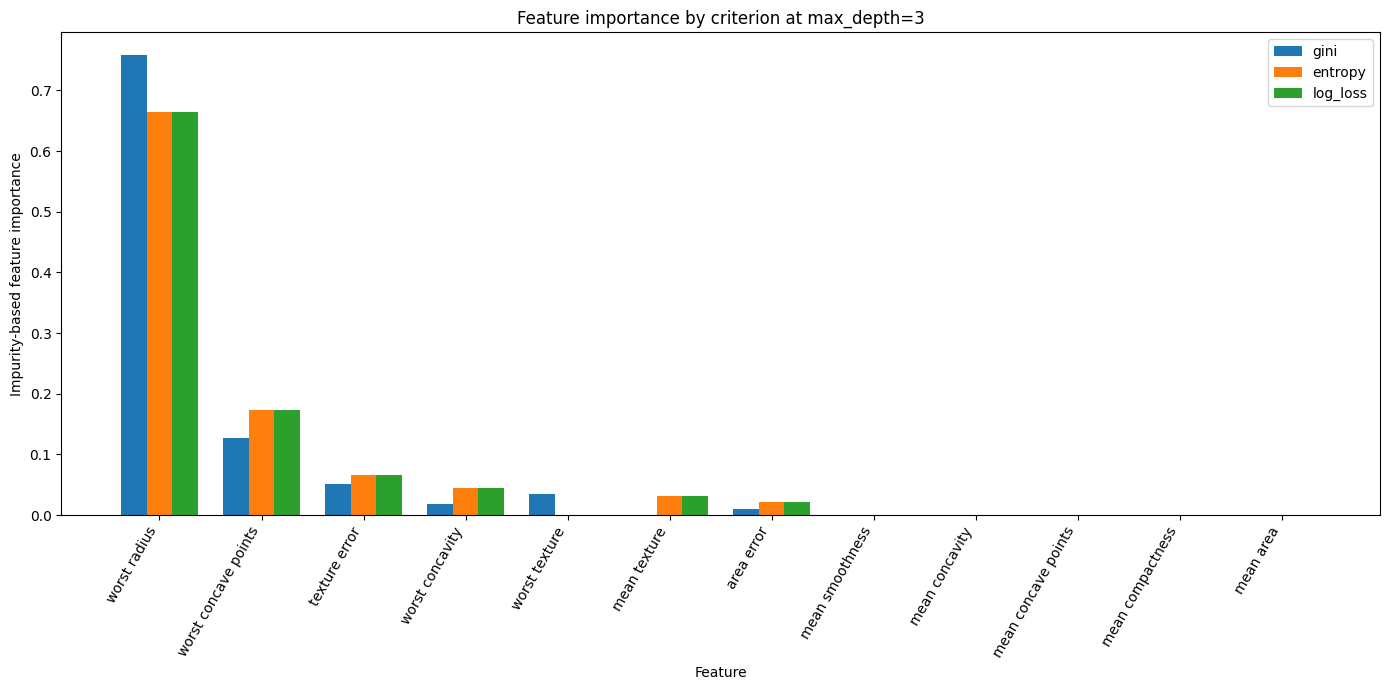

In [154]:
#| echo: false
plot_criterion_importance()


### Exercise 4 — criterion conclusions (10 minutes)

Answer using evidence from the tables and plots:

1. Which criterion gives the best test accuracy at depth 3?
2. Do `"entropy"` and `"log_loss"` produce the same tree here?
3. Does the best criterion stay best at every depth?
4. Do criteria agree on the most important feature?
5. Why should one avoid a universal claim that one criterion is always superior?

## 9. Final model diagnosis - 15 minutes

Select one depth and criterion based on your evidence.

The code below remains a single decision tree.

## Final model scores


In [155]:
#| echo: false
FINAL_DEPTH = 3
FINAL_CRITERION = "gini"

final_tree = DecisionTreeClassifier(
    max_depth=FINAL_DEPTH,
    criterion=FINAL_CRITERION,
    random_state=RANDOM_STATE,
)
final_tree.fit(X_train, y_train)

final_train_pred = final_tree.predict(X_train)
final_test_pred = final_tree.predict(X_test)

final_metrics = pd.Series({
    "train_accuracy": accuracy_score(y_train, final_train_pred),
    "test_accuracy": accuracy_score(y_test, final_test_pred),
    "test_balanced_accuracy": balanced_accuracy_score(y_test, final_test_pred),
    "actual_depth": final_tree.get_depth(),
    "n_leaves": final_tree.get_n_leaves(),
    "node_count": final_tree.tree_.node_count,
})
display(final_metrics.to_frame("value"))

,value
train_accuracy,0.976526
test_accuracy,0.944056
test_balanced_accuracy,0.936164
actual_depth,3.000000
n_leaves,7.000000
node_count,13.000000


## Final confusion matrix


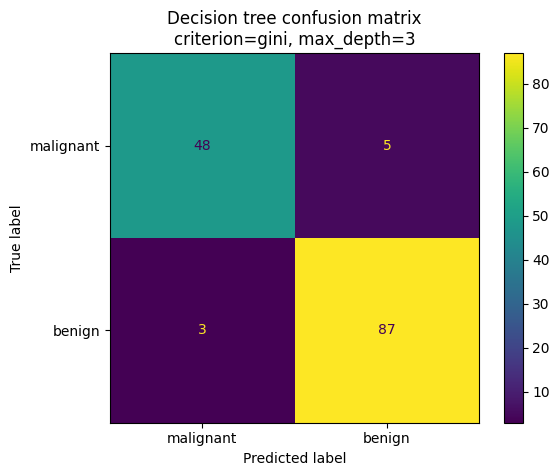

In [156]:
#| echo: false
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_test_pred,
    display_labels=dataset.target_names,
    cmap=None,
)
plt.title(
    f"Decision tree confusion matrix\n"
    f"criterion={FINAL_CRITERION}, max_depth={FINAL_DEPTH}"
)
plt.show()

## Final tree structure


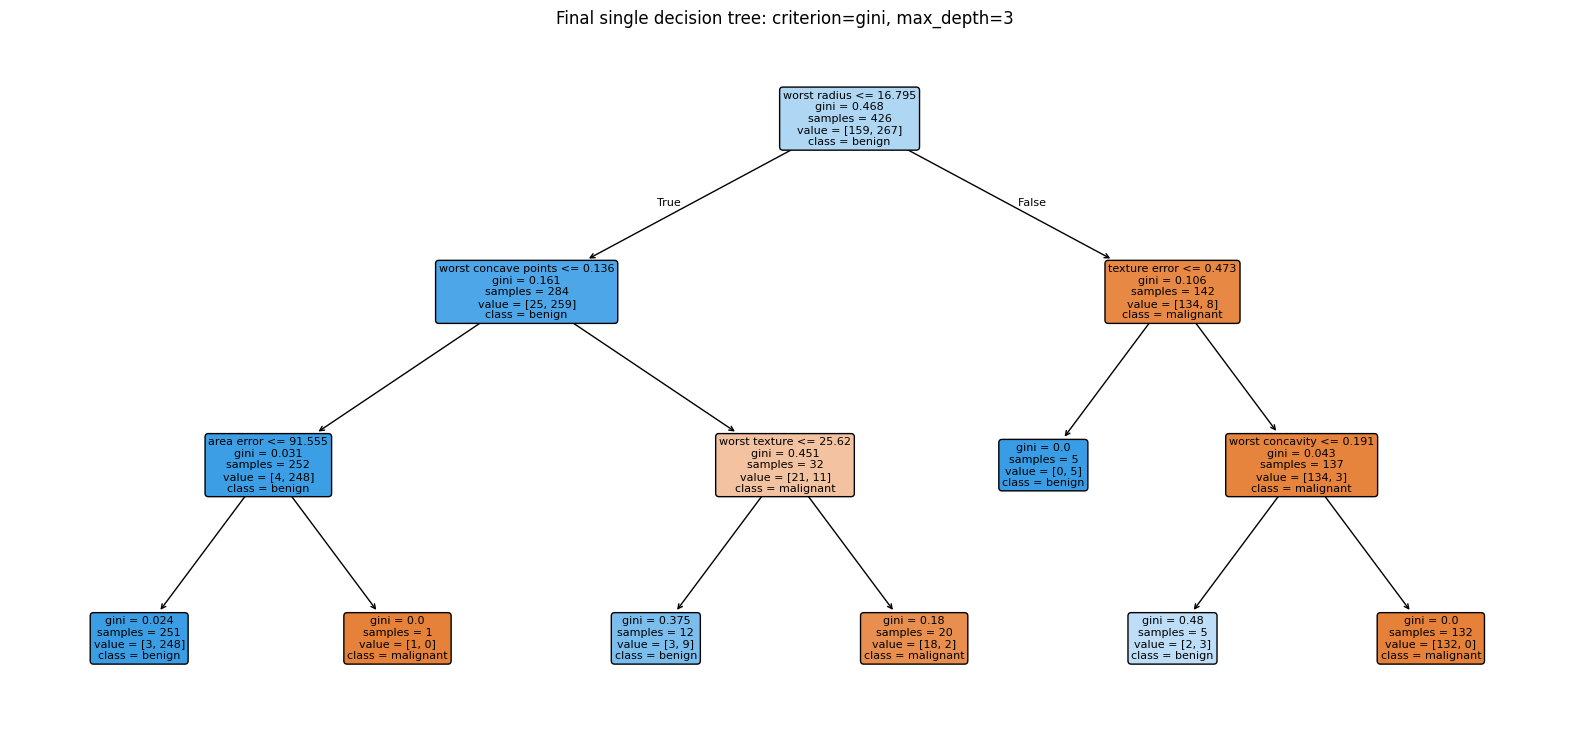

In [157]:
#| echo: false
plt.figure(figsize=(20, 9))
plot_tree(
    final_tree,
    feature_names=X.columns,
    class_names=dataset.target_names,
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=8,
)
plt.title(
    f"Final single decision tree: "
    f"criterion={FINAL_CRITERION}, max_depth={FINAL_DEPTH}"
)
plt.show()

## 10. Capstone tasks - 20 minutes

Complete these tasks without changing the model family.

### Task A — depth recommendation

Choose a maximum depth from 1 to 12. Defend the choice with at least three measurements.

### Task B — feature importance audit

For your selected tree:

1. List the five most important features.
2. Find every node that uses the top feature.
3. Sum that feature's unnormalized node contributions.
4. Verify that normalization reproduces `feature_importances_`.

### Task C — purity criterion comparison

At your chosen depth:

1. Train one tree per criterion.
2. Compare root split, leaves, accuracy, log loss, and top features.
3. Explain why different impurity functions may lead to similar or different trees.

### Task D — written synthesis

Write 150–250 words answering:

> How do depth and purity criterion affect tree complexity, generalization, leaf purity, and impurity-based feature importance?

In [158]:
#| echo: false
#| output: false
SELECTED_DEPTH = 3

capstone_models = {
    criterion: DecisionTreeClassifier(
        max_depth=SELECTED_DEPTH,
        criterion=criterion,
        random_state=RANDOM_STATE,
    ).fit(X_train, y_train)
    for criterion in criteria
}

capstone_rows = []
for criterion, model in capstone_models.items():
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)
    top_features = (
        pd.Series(model.feature_importances_, index=X.columns)
        .sort_values(ascending=False)
        .head(5)
    )

    capstone_rows.append({
        "criterion": criterion,
        "test_accuracy": accuracy_score(y_test, predictions),
        "test_log_loss": log_loss(y_test, probabilities),
        "actual_depth": model.get_depth(),
        "n_leaves": model.get_n_leaves(),
        "root_feature": X.columns[model.tree_.feature[0]],
        "top_5_features": ", ".join(top_features.index),
    })

capstone_comparison = pd.DataFrame(capstone_rows).set_index("criterion")


## Capstone comparison table


In [159]:
#| echo: false
display(capstone_comparison)


,test_accuracy,test_log_loss,actual_depth,n_leaves,root_feature,top_5_features
criterion,,,,,,
gini,0.944056,0.876332,3,7,worst radius,"worst radius, worst concave points, texture er..."
entropy,0.951049,0.874367,3,7,worst radius,"worst radius, worst concave points, texture er..."
log_loss,0.951049,0.874367,3,7,worst radius,"worst radius, worst concave points, texture er..."


## 11. Key takeaways

- `max_depth` directly limits how many successive decisions a path can contain.
- Increasing depth usually lowers training impurity and raises training accuracy.
- Deeper is not automatically better: test performance can plateau or worsen.
- Gini, entropy, and log-loss criteria quantify class mixture differently.
- Criterion choice can change split features, thresholds, topology, predictions, and importances.
- Tree feature importance is normalized accumulated weighted impurity decrease.
- Importance depends on the fitted tree and should not be interpreted as causality.
- A useful tree balances predictive performance, stability, and interpretability.

## References

Official scikit-learn documentation:

- `DecisionTreeClassifier`
- Decision Trees user guide
- `plot_tree`
- `load_iris`
- `load_breast_cancer`
- Tree structure example
- Impurity-based feature importance examples

The notebook intentionally uses only a single-tree classifier for model training.